In [71]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA
import pylab as pl
from itertools import cycle

# Importando parâmetros

In [72]:
data = pd.read_csv('param_clean.csv')

data.head()

,artigo,grupo,tag,molecules,smiles,Formula molecular,Massa molar,lambda max linear (nm),mu01 (D),mu12 (D),mu13 (D),deltamu01 (D),Seção de choque(GM),solvente,simetria,Bandas TPA,doi
0,1,1.0,1A,(E)-chalcone,O=C(C1=CC=CC=C1)/C=C/C2=CC=CC=C2,C15H12O,208.25,308,6.24,5.29,0.0,3.93,9,methanol,Asymmetric,1,https://doi.org/10.1016/j.cplett.2016.02.009
1,1,1.0,1B,(E)-3-(4-methoxyphenyl)-1-phenylprop-2-en-1-one,O=C(C1=CC=CC=C1)/C=C/C2=CC=C(OC)C=C2,C16H14O2,238.28,343,3.38,7.62,0.0,7.87,14,methanol,Asymmetric,1,https://doi.org/10.1016/j.cplett.2016.02.009
2,2,NaN,2,"1E,4E-1-(4-chlorophenyl)-5-(2,6,6- trimethylc...",O=C(/C=C/C1=C(C)CCCC1(C)C)/C=C/C2=CC=C(Cl)C=C2,C20H23ClO,314.84,328,NaN,NaN,NaN,NaN,32,dmso,Asymmetric,1,https://doi.org/10.1016/j.saa.2018.06.099
3,3,2.0,3,(E)-3-(2-bromophenyl)-1-(2-((phenylsulfonyl)am...,O=C(C1=CC=CC=C1NS(=O)(C2=CC=CC=C2)=O)/C=C/C3=C...,C21H16BrNO3SNa,442.32,315,7.60,4.40,4.4,3.10,17,dmso,Asymmetric,2,https://doi.org/10.1021/acs.jpcc.9b01063
4,4,2.0,4A,(E)-3-(2-chlorophenyl)-1-(2-(phenylsulfonylami...,O=C(C1=CC=CC=C1NS(=O)(C2=CC=CC=C2)=O)/C=C/C3=C...,C21H16ClNO3S,397.87,318,6.40,4.00,4.0,4.60,12,dmso,Asymmetric,2,https://doi.org/10.1016/j.molstruc.2019.126896


In [73]:
data.columns

Index(['artigo', 'grupo', 'tag', 'molecules', 'smiles', 'Formula molecular',
       'Massa molar', 'lambda max linear (nm)', 'mu01 (D)', 'mu12 (D)',
       'mu13 (D)', 'deltamu01 (D)', 'Seção de choque(GM)', 'solvente',
       'simetria', 'Bandas TPA', 'doi'],
      dtype='object')

In [74]:
data_aux = data.copy()


In [75]:
#limpando valores vazios
data.dropna(axis=0, how='any',inplace=True)

# Parâmetros mistos

In [76]:
y = data.iloc[:, 9]

data.drop("Seção de choque(GM)", axis=1, inplace= True)
data.head(3)

,artigo,grupo,tag,molecules,smiles,Formula molecular,Massa molar,lambda max linear (nm),mu01 (D),mu12 (D),mu13 (D),deltamu01 (D),solvente,simetria,Bandas TPA,doi
0,1,1.0,1A,(E)-chalcone,O=C(C1=CC=CC=C1)/C=C/C2=CC=CC=C2,C15H12O,208.25,308,6.24,5.29,0.0,3.93,methanol,Asymmetric,1,https://doi.org/10.1016/j.cplett.2016.02.009
1,1,1.0,1B,(E)-3-(4-methoxyphenyl)-1-phenylprop-2-en-1-one,O=C(C1=CC=CC=C1)/C=C/C2=CC=C(OC)C=C2,C16H14O2,238.28,343,3.38,7.62,0.0,7.87,methanol,Asymmetric,1,https://doi.org/10.1016/j.cplett.2016.02.009
3,3,2.0,3,(E)-3-(2-bromophenyl)-1-(2-((phenylsulfonyl)am...,O=C(C1=CC=CC=C1NS(=O)(C2=CC=CC=C2)=O)/C=C/C3=C...,C21H16BrNO3SNa,442.32,315,7.60,4.40,4.4,3.10,dmso,Asymmetric,2,https://doi.org/10.1021/acs.jpcc.9b01063


In [77]:
num_vars = ['lambda max linear (nm)', 'mu01 (D)', 'mu12 (D)', 'mu13 (D)',
       'deltamu01 (D)', 'Bandas TPA']
cat_vars =['solvente','simetria']

data_num = data[num_vars].copy()
data_cat = data[cat_vars].copy()



In [78]:
scaler = StandardScaler()
data_num_scaled = scaler.fit_transform(data_num)

In [79]:
encoder = OneHotEncoder()
data_cat_encoded = encoder.fit_transform(data_cat)

data_cat_encoded = pd.DataFrame(data_cat_encoded)

In [80]:
encoder = OneHotEncoder()
data_cat_encoded = encoder.fit_transform(data_cat)

freqs = data_cat_encoded.mean(axis=0)
data_cat_scaled = data_cat_encoded / np.sqrt(freqs)

data_cat_scaled -= data_cat_scaled.mean(axis=0) #centralização das colunas

In [81]:
X = np.hstack((data_num_scaled, data_cat_scaled))

num_col_names = num_vars
cat_col_names = encoder.get_feature_names_out(cat_vars)

col_names = list(num_col_names) + list(cat_col_names)

In [82]:
X = pd.DataFrame(X, columns= ['λ\u2081 max', ' μ\u2080\u2081', 'μ\u2081\u2082', 'μ\u2081\u2083',
       'Δμ\u2080\u2081','Bandas TPA', 'DCM', 'DMSO', 'Methanol', 'Assimétrica', 'Simétrica'])

X.head(3)

,λ₁ max,μ₀₁,μ₁₂,μ₁₃,Δμ₀₁,Bandas TPA,DCM,DMSO,Methanol,Assimétrica,Simétrica
0,-0.977001,0.154456,0.791784,-0.59723,-0.852937,-0.948683,-0.489898,-0.824621,3.252691,0.12792,-0.34641
1,0.318265,-1.117851,1.738057,-0.59723,0.374445,-0.948683,-0.489898,-0.824621,3.252691,0.12792,-0.34641
2,-0.717948,0.759469,0.430331,0.23541,-1.111497,0.632456,-0.489898,0.388057,-0.282843,0.12792,-0.34641


In [83]:
X.describe().round(2)

,λ₁ max,μ₀₁,μ₁₂,μ₁₃,Δμ₀₁,Bandas TPA,DCM,DMSO,Methanol,Assimétrica,Simétrica
count,25.00,25.00,25.00,25.00,25.00,25.00,25.00,25.00,25.00,25.00,25.00
mean,0.00,0.00,-0.00,-0.00,0.00,-0.00,0.00,-0.00,0.00,-0.00,-0.00
std,1.02,1.02,1.02,1.02,1.02,1.02,0.89,0.58,0.98,0.35,0.96
min,-2.38,-2.18,-1.36,-0.60,-1.77,-0.95,-0.49,-0.82,-0.28,-0.94,-0.35
25%,-0.61,-0.75,-0.54,-0.60,-0.85,-0.95,-0.49,-0.82,-0.28,0.13,-0.35
50%,-0.16,0.14,-0.06,-0.26,-0.05,0.63,-0.49,0.39,-0.28,0.13,-0.35
75%,0.58,0.71,0.55,0.24,0.45,0.63,-0.49,0.39,-0.28,0.13,-0.35
max,3.24,1.56,1.81,4.23,2.32,2.21,1.55,0.39,3.25,0.13,2.54


In [84]:
pca = PCA()
X_pca = pca.fit_transform(X)

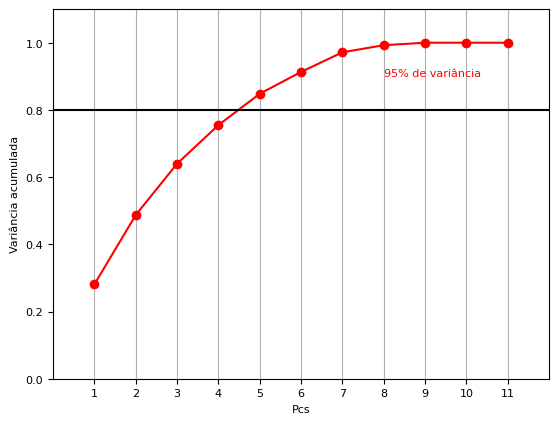

In [85]:
fig, ax = plt.subplots()

plt.xlabel('Pcs')
plt.ylabel("Variância acumulada")


plt.plot(range(1,len(pca.explained_variance_ratio_)+1), np.cumsum(pca.explained_variance_ratio_),marker='o', c = 'red')

plt.ylim(0,1.1)
plt.xlim(0,12)

plt.xticks(np.arange(1,12, step=1))

plt.axhline(y=0.80, color='black', linestyle='-')
plt.text(8, 0.90, '95% de variância', color = 'red', fontsize=8)

ax.grid(axis='x')
plt.show()

In [86]:
pca_loadings = pca.components_.T * np.sqrt(pca.explained_variance_)
pca_loadings_df = pd.DataFrame(pca_loadings, columns=X.columns, index=[f'PC{i+1}' for i in range(pca_loadings.shape[0])])
pca_loadings_df.head(3)

,λ₁ max,μ₀₁,μ₁₂,μ₁₃,Δμ₀₁,Bandas TPA,DCM,DMSO,Methanol,Assimétrica,Simétrica
PC1,-0.130507,0.273769,-0.529083,0.775261,0.051553,0.076383,-0.206404,0.123613,-0.048493,-0.000000e+00,0.000000e+00
PC2,0.187355,0.841151,0.082373,-0.101277,-0.457498,-0.106252,-0.193290,0.084071,0.130250,-2.986413e-32,2.815410e-34
PC3,-0.545617,0.002772,0.498475,0.481084,-0.150289,-0.166215,0.455630,0.066745,0.042121,-5.716350e-32,-5.083576e-34


In [87]:
columns = X.columns.values

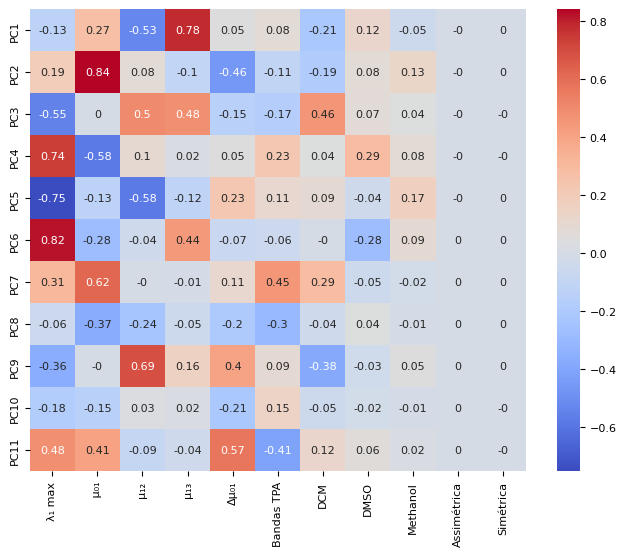

In [89]:
plt.figure(figsize=(8, 6))
sns.heatmap(pca_loadings_df.round(2), cmap="coolwarm", annot=True)
plt.show()

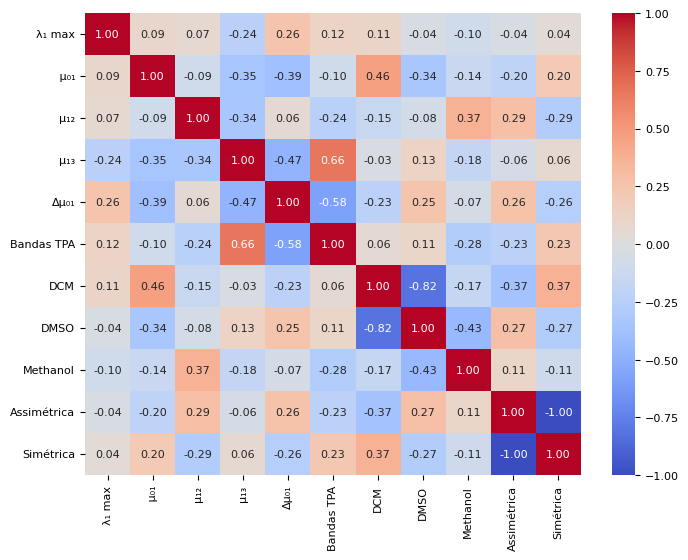

In [90]:
#Mapa de correlações das variáveis
corr = X.corr()

# Plotar o heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.show()

# Sem os parametros de simetria

In [91]:
data_ = data.copy()
data_.drop("simetria", axis=1, inplace= True)
data_.head()

,artigo,grupo,tag,molecules,smiles,Formula molecular,Massa molar,lambda max linear (nm),mu01 (D),mu12 (D),mu13 (D),deltamu01 (D),solvente,Bandas TPA,doi
0,1,1.0,1A,(E)-chalcone,O=C(C1=CC=CC=C1)/C=C/C2=CC=CC=C2,C15H12O,208.25,308,6.24,5.29,0.0,3.93,methanol,1,https://doi.org/10.1016/j.cplett.2016.02.009
1,1,1.0,1B,(E)-3-(4-methoxyphenyl)-1-phenylprop-2-en-1-one,O=C(C1=CC=CC=C1)/C=C/C2=CC=C(OC)C=C2,C16H14O2,238.28,343,3.38,7.62,0.0,7.87,methanol,1,https://doi.org/10.1016/j.cplett.2016.02.009
3,3,2.0,3,(E)-3-(2-bromophenyl)-1-(2-((phenylsulfonyl)am...,O=C(C1=CC=CC=C1NS(=O)(C2=CC=CC=C2)=O)/C=C/C3=C...,C21H16BrNO3SNa,442.32,315,7.60,4.40,4.4,3.10,dmso,2,https://doi.org/10.1021/acs.jpcc.9b01063
4,4,2.0,4A,(E)-3-(2-chlorophenyl)-1-(2-(phenylsulfonylami...,O=C(C1=CC=CC=C1NS(=O)(C2=CC=CC=C2)=O)/C=C/C3=C...,C21H16ClNO3S,397.87,318,6.40,4.00,4.0,4.60,dmso,2,https://doi.org/10.1016/j.molstruc.2019.126896
5,4,2.0,4B,(E)-3-(2-fluoro-phenyl)-1-(2-(phenylsulfonylam...,O=C(C1=CC=CC=C1NS(=O)(C2=CC=CC=C2)=O)/C=C/C3=C...,C21H16FNO3S,381.42,318,7.20,4.40,4.5,3.80,dmso,2,https://doi.org/10.1016/j.molstruc.2019.126896


In [92]:
num_vars2 = ['lambda max linear (nm)', 'mu01 (D)', 'mu12 (D)', 'mu13 (D)',
       'deltamu01 (D)','Bandas TPA']
cat_vars2 =['solvente']

data_num2 = data[num_vars2].copy()
data_cat2 = data[cat_vars2].copy()

In [93]:
scaler = StandardScaler()
data_num_scaled2 = scaler.fit_transform(data_num2)

In [94]:
encoder = OneHotEncoder()
data_cat_encoded2 = encoder.fit_transform(data_cat2)

freqs2 = data_cat_encoded2.mean(axis=0)
data_cat_scaled2 = data_cat_encoded2 / np.sqrt(freqs2)

data_cat_scaled2 -= data_cat_scaled2.mean(axis=0) #centralização das colunas

In [95]:
X_ = np.hstack((data_num_scaled2, data_cat_scaled2))

num_col_names2 = num_vars2
cat_col_names2 = encoder.get_feature_names_out(cat_vars2)

col_names2 = list(num_col_names2) + list(cat_col_names2)
col_names2

['lambda max linear (nm)',
 'mu01 (D)',
 'mu12 (D)',
 'mu13 (D)',
 'deltamu01 (D)',
 'Bandas TPA',
 'solvente_dcm',
 'solvente_dmso',
 'solvente_methanol']

In [96]:
X_ = pd.DataFrame(X_, columns= ['λ\u2081 max', ' μ\u2080\u2081', 'μ\u2081\u2082', 'μ\u2081\u2083',
       'Δμ\u2080\u2081','Bandas TPA', 'DCM', 'DMSO', 'Methanol'])

X_.head(3)

,λ₁ max,μ₀₁,μ₁₂,μ₁₃,Δμ₀₁,Bandas TPA,DCM,DMSO,Methanol
0,-0.977001,0.154456,0.791784,-0.59723,-0.852937,-0.948683,-0.489898,-0.824621,3.252691
1,0.318265,-1.117851,1.738057,-0.59723,0.374445,-0.948683,-0.489898,-0.824621,3.252691
2,-0.717948,0.759469,0.430331,0.23541,-1.111497,0.632456,-0.489898,0.388057,-0.282843


In [97]:
X_.describe().round(2)

,λ₁ max,μ₀₁,μ₁₂,μ₁₃,Δμ₀₁,Bandas TPA,DCM,DMSO,Methanol
count,25.00,25.00,25.00,25.00,25.00,25.00,25.00,25.00,25.00
mean,0.00,0.00,-0.00,-0.00,0.00,-0.00,0.00,-0.00,0.00
std,1.02,1.02,1.02,1.02,1.02,1.02,0.89,0.58,0.98
min,-2.38,-2.18,-1.36,-0.60,-1.77,-0.95,-0.49,-0.82,-0.28
25%,-0.61,-0.75,-0.54,-0.60,-0.85,-0.95,-0.49,-0.82,-0.28
50%,-0.16,0.14,-0.06,-0.26,-0.05,0.63,-0.49,0.39,-0.28
75%,0.58,0.71,0.55,0.24,0.45,0.63,-0.49,0.39,-0.28
max,3.24,1.56,1.81,4.23,2.32,2.21,1.55,0.39,3.25


In [98]:
pca_ = PCA()
X_pca2 = pca_.fit_transform(X_)

In [99]:
sum  = 0
for i in range (0,4):
  sum += pca_.explained_variance_ratio_[i]
sum*100

np.float64(81.23959719156169)

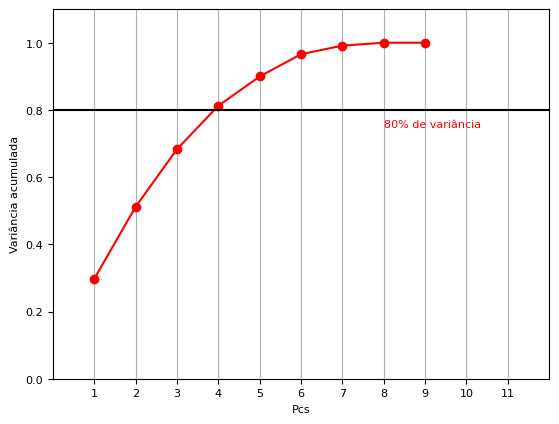

In [100]:
fig, ax = plt.subplots()

plt.xlabel('Pcs')
plt.ylabel("Variância acumulada")


plt.plot(range(1,len(pca_.explained_variance_ratio_)+1), np.cumsum(pca_.explained_variance_ratio_),marker='o', c = 'red')

plt.ylim(0,1.1)
plt.xlim(0,12)

plt.xticks(np.arange(1,12, step=1))

plt.axhline(y=0.80, color='black', linestyle='-')
plt.text(8, 0.75, '80% de variância', color = 'red', fontsize=8)

ax.grid(axis='x')
plt.show()

In [101]:
opt_num = 5

In [127]:
df_grupos = pd.DataFrame(data= X_pca2[:, 0:4], columns=['PC1', 'PC2', 'PC3','PC4'])
df_grupos = pd.concat([df_grupos, data_[['grupo', 'artigo']]], axis=1)
df_grupos.head()

,PC1,PC2,PC3,PC4,grupo,artigo
0,-1.396038,0.204506,3.296568,-0.085746,1.0,1.0
1,-2.459914,-0.842700,2.566258,1.351948,1.0,1.0
2,0.973577,0.244550,0.774313,-0.108428,NaN,NaN
3,0.743632,-0.204850,0.442761,-0.083712,2.0,3.0
4,0.865286,0.074468,0.629117,-0.025284,2.0,4.0


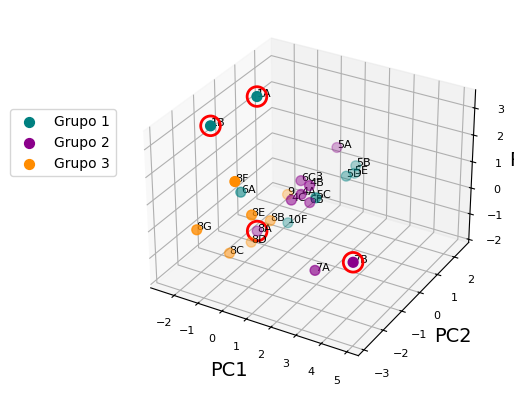

In [103]:
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

data_filtered = data_.loc[data.index]

for i, txt in enumerate(data_filtered['tag']):
   ax.text(X_pca2[i,0], X_pca2[i,1], X_pca2[i,2], txt, fontsize=8)

targets = list(range(1,4))
colors = ['teal', 'darkmagenta', 'darkorange']
fig.patch.set_facecolor('white')
handles = []
for target, color in zip(targets,colors):
    indicesToKeep = df_grupos['grupo'] == target
    scatter = ax.scatter(df_grupos.loc[indicesToKeep, 'PC1'], df_grupos.loc[indicesToKeep, 'PC2'],
               df_grupos.loc[indicesToKeep, 'PC3'],
               c = color
               , s = 50)
    handles.append(scatter)

# Highlight points with 'artigo' values 1 and 7
pontos_destaque_indices = df_grupos[df_grupos['artigo'].isin([1, 7])].index

for i in pontos_destaque_indices:
    ax.scatter(X_pca2[i,0], X_pca2[i,1], X_pca2[i,2], facecolors='none', edgecolors='red', s=200, linewidths=2)


ax.set_xlabel("PC1", fontsize=14)
ax.set_ylabel("PC2", fontsize=14)
ax.set_zlabel("PC3", fontsize=14)
labels = [f'Grupo {i}' for i in targets]


ax.legend(labels, fontsize = 10, bbox_to_anchor = (0, 0.75))
ax.grid()
plt.savefig("plot3d_param_s_sim.png", dpi=300)
plt.show()

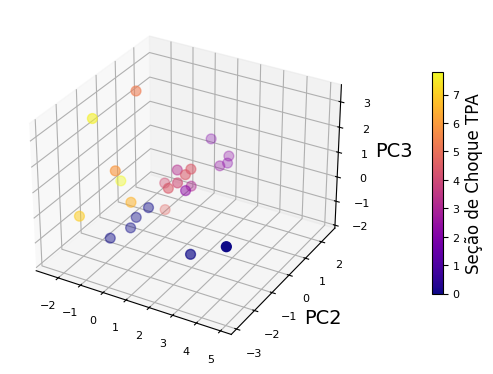

In [126]:
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

data_filtered = data_.loc[data.index]

fig.patch.set_facecolor('white')

scatter = ax.scatter(df_grupos['PC1'], df_grupos['PC2'],
               df_grupos['PC3'],
               c = y, cmap ='plasma'
               , s = 50)


ax.set_ylabel("PC2", fontsize=14)
ax.set_zlabel("PC3", fontsize=14)


cbar = plt.colorbar(scatter, ax = ax, shrink = 0.6, pad = 0.15)
cbar.set_label('Seção de Choque TPA', fontsize=12)


ax.grid()
plt.savefig("plot3d_param_sc.png", dpi=300)
plt.show()